# Isekai vs Cultivation — Exploratory Data Analysis (v2)

**Research Question:** Did the isekai anime genre and Chinese cultivation web novel genre undergo similar patterns of boom, saturation, and quality decline? Did these trends happen simultaneously or did one precede the other?

**Key fixes in v2:**
- Novels filtered to `vote_count >= 5` to remove unrated entries
- Regression trend lines added to quality-over-time chart
- Transmigration explosion annotated on tag chart
- Headline finding highlighted in summary

## 1. Setup & Data Loading

In [15]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ANIME_COLOR  = '#4C72B0'
NOVEL_COLOR  = '#DD8452'
ACCENT_COLOR = '#55A868'
BAD_COLOR    = '#C44E52'

DB_PATH = 'isekai_vs_cultivation.db'
conn = sqlite3.connect(DB_PATH)
print('Connected:', DB_PATH)

Connected: isekai_vs_cultivation.db


In [16]:
novels_raw = pd.read_sql_query('SELECT * FROM novels', conn)
anime      = pd.read_sql_query('SELECT * FROM anime',  conn)

novel_genres_df    = pd.read_sql_query('SELECT ng.novel_id, g.name AS genre FROM novel_genres ng JOIN genres g ON ng.genre_id = g.id', conn)
novel_tags_df      = pd.read_sql_query('SELECT nt.novel_id, t.name AS tag FROM novel_tags nt JOIN tags t ON nt.tag_id = t.id', conn)
novel_authors_df   = pd.read_sql_query('SELECT na.novel_id, a.name AS author, a.name_type FROM novel_authors na JOIN authors a ON na.author_id = a.id', conn)
novel_publishers_df= pd.read_sql_query('SELECT np.novel_id, p.name AS publisher FROM novel_publishers np JOIN publishers p ON np.publisher_id = p.id', conn)
anime_genres_df    = pd.read_sql_query('SELECT ag.anime_id, g.name AS genre FROM anime_genres ag JOIN genres g ON ag.genre_id = g.id', conn)
anime_themes_df    = pd.read_sql_query('SELECT at.anime_id, t.name AS theme FROM anime_themes at JOIN themes t ON at.theme_id = t.id', conn)
anime_studios_df   = pd.read_sql_query('SELECT as_.anime_id, s.name AS studio FROM anime_studios as_ JOIN studios s ON as_.studio_id = s.id', conn)

# ── Type conversions ───────────────────────────────────────────────────────
novels_raw['year']              = pd.to_numeric(novels_raw['year'], errors='coerce')
novels_raw['rating']            = pd.to_numeric(novels_raw['rating'], errors='coerce')
novels_raw['num_chapters']      = pd.to_numeric(novels_raw['num_chapters'], errors='coerce')
novels_raw['reading_list_count']= pd.to_numeric(novels_raw['reading_list_count'], errors='coerce')
novels_raw['vote_count']        = pd.to_numeric(novels_raw['vote_count'], errors='coerce')

anime['start_year'] = pd.to_datetime(anime['start_date'], errors='coerce').dt.year
anime['mean']       = pd.to_numeric(anime['mean'], errors='coerce')
anime['members']    = pd.to_numeric(anime['members'], errors='coerce')
anime['popularity'] = pd.to_numeric(anime['popularity'], errors='coerce')
anime['num_scoring_users'] = pd.to_numeric(anime['num_scoring_users'], errors='coerce')

# ── KEY FIX: filter out unrated novels (vote_count < 5) ───────────────────
novels = novels_raw[novels_raw['vote_count'] >= 5].copy()

print(f'Novels (raw):     {len(novels_raw):,}')
print(f'Novels (rated):   {len(novels):,}  (vote_count >= 5)')
print(f'Anime:            {len(anime):,}')
print(f'Removed:          {len(novels_raw) - len(novels):,} unrated novels')

Novels (raw):     3,869
Novels (rated):   2,936  (vote_count >= 5)
Anime:            1,314
Removed:          933 unrated novels


## 2. Dataset Overview

In [17]:
print('=' * 55)
print('CULTIVATION NOVELS (rated only)')
print('=' * 55)
print(f"Total (rated):         {len(novels):,}")
print(f"Year range:            {int(novels['year'].min())} – {int(novels['year'].max())}")
print(f"Avg rating:            {novels['rating'].mean():.3f} / 5.0")
print(f"Median rating:         {novels['rating'].median():.3f} / 5.0")
print(f"Avg chapters:          {novels['num_chapters'].mean():.0f}")
print(f"Completed:             {(novels['status'] == 'Completed').sum():,}")
print(f"Ongoing:               {(novels['status'] == 'Ongoing').sum():,}")

print()
print('=' * 55)
print('ISEKAI ANIME')
print('=' * 55)
print(f"Total:                 {len(anime):,}")
print(f"Year range:            {int(anime['start_year'].min())} – {int(anime['start_year'].max())}")
print(f"Avg score:             {anime['mean'].mean():.3f} / 10.0")
print(f"Median score:          {anime['mean'].median():.3f} / 10.0")
print(f"Avg episodes:          {anime['num_episodes'].mean():.1f}")
print(f"Source breakdown:")
for src, cnt in anime['source'].value_counts().head(5).items():
    print(f"  {src:<20} {cnt}")

CULTIVATION NOVELS (rated only)
Total (rated):         2,936
Year range:            2001 – 2026
Avg rating:            3.571 / 5.0
Median rating:         3.600 / 5.0
Avg chapters:          nan
Completed:             1,306
Ongoing:               489

ISEKAI ANIME
Total:                 1,314
Year range:            1967 – 2026
Avg score:             6.880 / 10.0
Median score:          6.870 / 10.0
Avg episodes:          21.3
Source breakdown:
  manga                294
  light_novel          275
  web_novel            231
  original             195
  game                 86


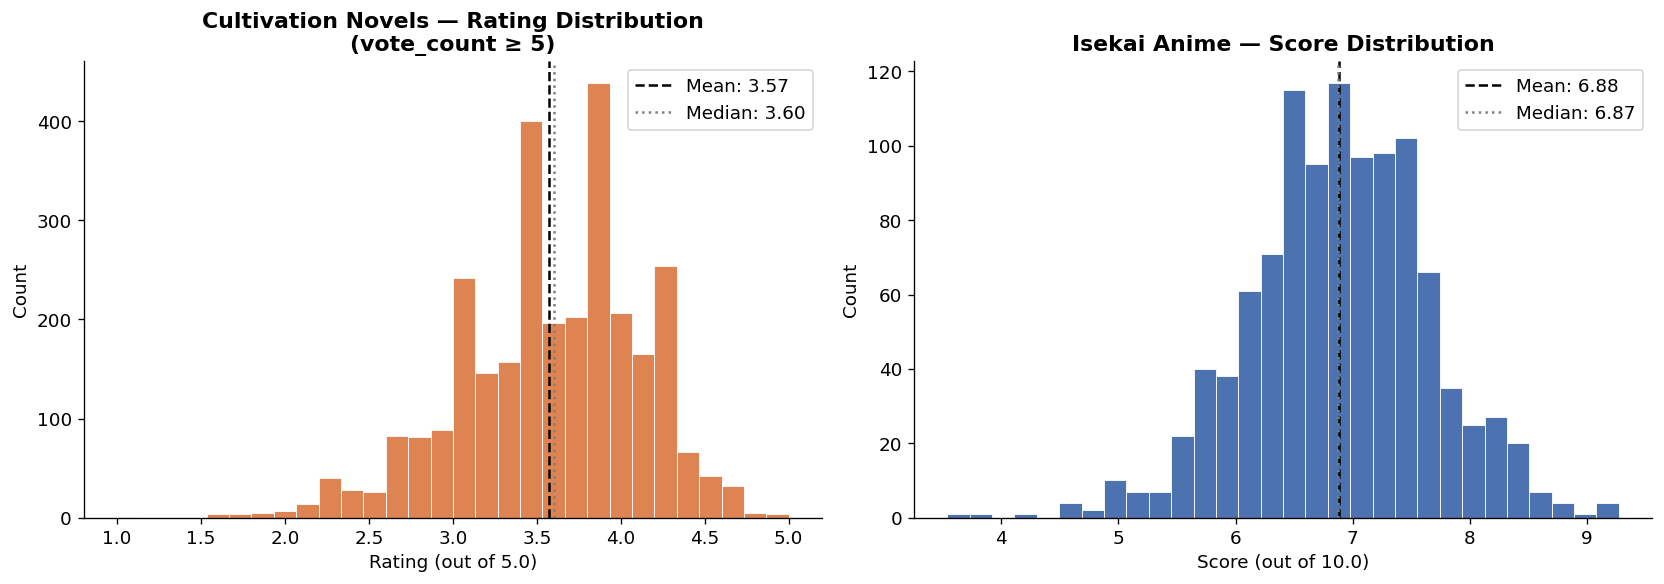

In [18]:
# Rating distributions — now without the 0-rating spike
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(novels['rating'].dropna(), bins=30, color=NOVEL_COLOR, edgecolor='white', linewidth=0.5)
axes[0].axvline(novels['rating'].mean(), color='black', linestyle='--', linewidth=1.5,
                label=f"Mean: {novels['rating'].mean():.2f}")
axes[0].axvline(novels['rating'].median(), color='gray', linestyle=':', linewidth=1.5,
                label=f"Median: {novels['rating'].median():.2f}")
axes[0].set_title('Cultivation Novels — Rating Distribution\n(vote_count ≥ 5)', fontweight='bold')
axes[0].set_xlabel('Rating (out of 5.0)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(anime['mean'].dropna(), bins=30, color=ANIME_COLOR, edgecolor='white', linewidth=0.5)
axes[1].axvline(anime['mean'].mean(), color='black', linestyle='--', linewidth=1.5,
                label=f"Mean: {anime['mean'].mean():.2f}")
axes[1].axvline(anime['mean'].median(), color='gray', linestyle=':', linewidth=1.5,
                label=f"Median: {anime['mean'].median():.2f}")
axes[1].set_title('Isekai Anime — Score Distribution', fontweight='bold')
axes[1].set_xlabel('Score (out of 10.0)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('01_rating_distributions_v2.png', bbox_inches='tight')
plt.show()

## 3. Part 1 — Timeline Analysis

In [19]:
novel_by_year = novels.groupby('year').agg(
    count=('id', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()
novel_by_year = novel_by_year[(novel_by_year['year'] >= 2010) & (novel_by_year['year'] <= 2025)]

anime_by_year = anime.groupby('start_year').agg(
    count=('id', 'count'),
    avg_score=('mean', 'mean')
).reset_index().rename(columns={'start_year': 'year'})
anime_by_year = anime_by_year[(anime_by_year['year'] >= 2010) & (anime_by_year['year'] <= 2025)]

print('Annual data ready.')

Annual data ready.


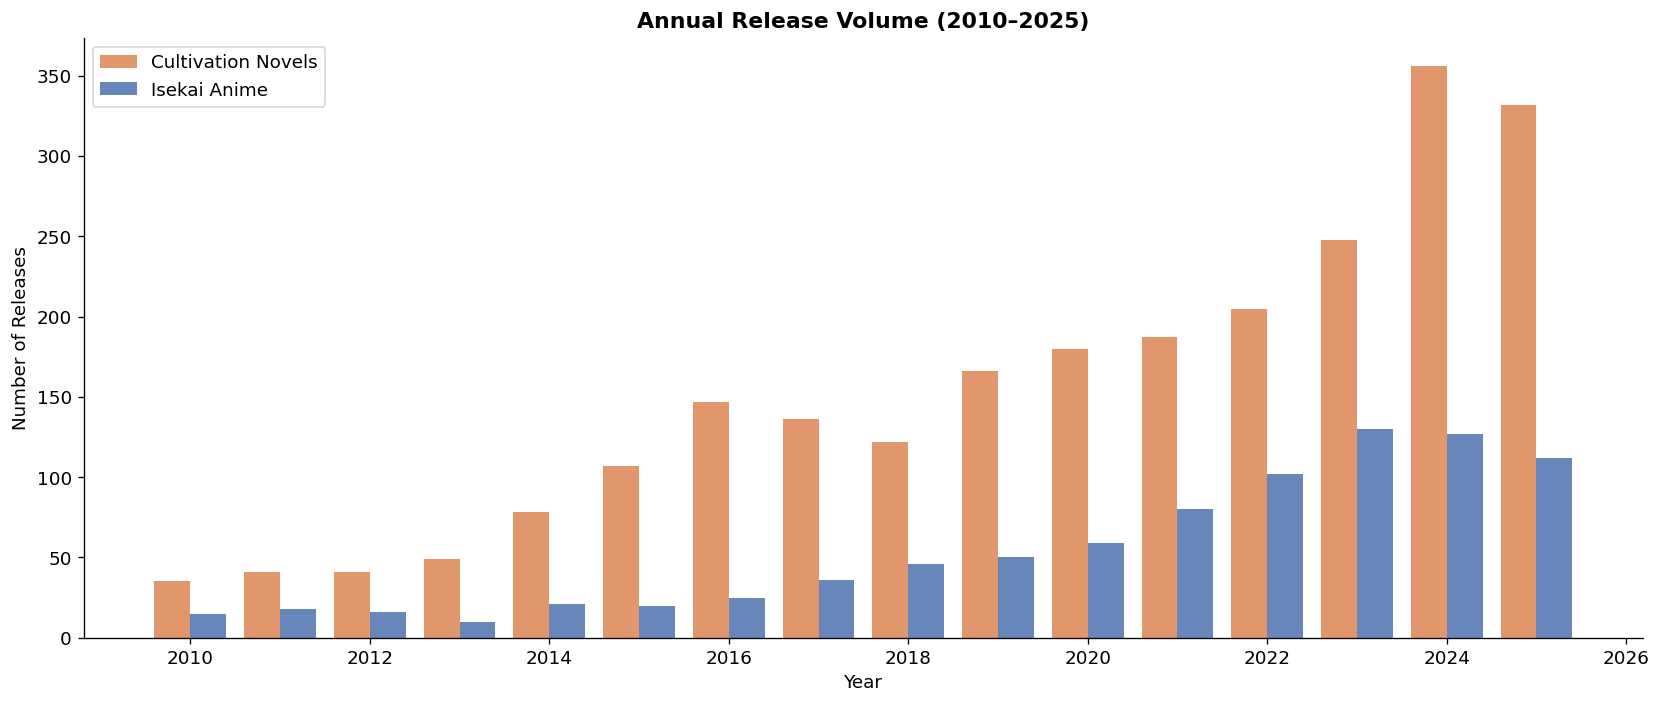

In [20]:
# ── Volume chart ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(novel_by_year['year'] - 0.2, novel_by_year['count'],
       width=0.4, color=NOVEL_COLOR, alpha=0.85, label='Cultivation Novels')
ax.bar(anime_by_year['year'] + 0.2, anime_by_year['count'],
       width=0.4, color=ANIME_COLOR, alpha=0.85, label='Isekai Anime')

ax.set_title('Annual Release Volume (2010–2025)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Releases')
ax.legend()
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig('02_annual_volume.png', bbox_inches='tight')
plt.show()

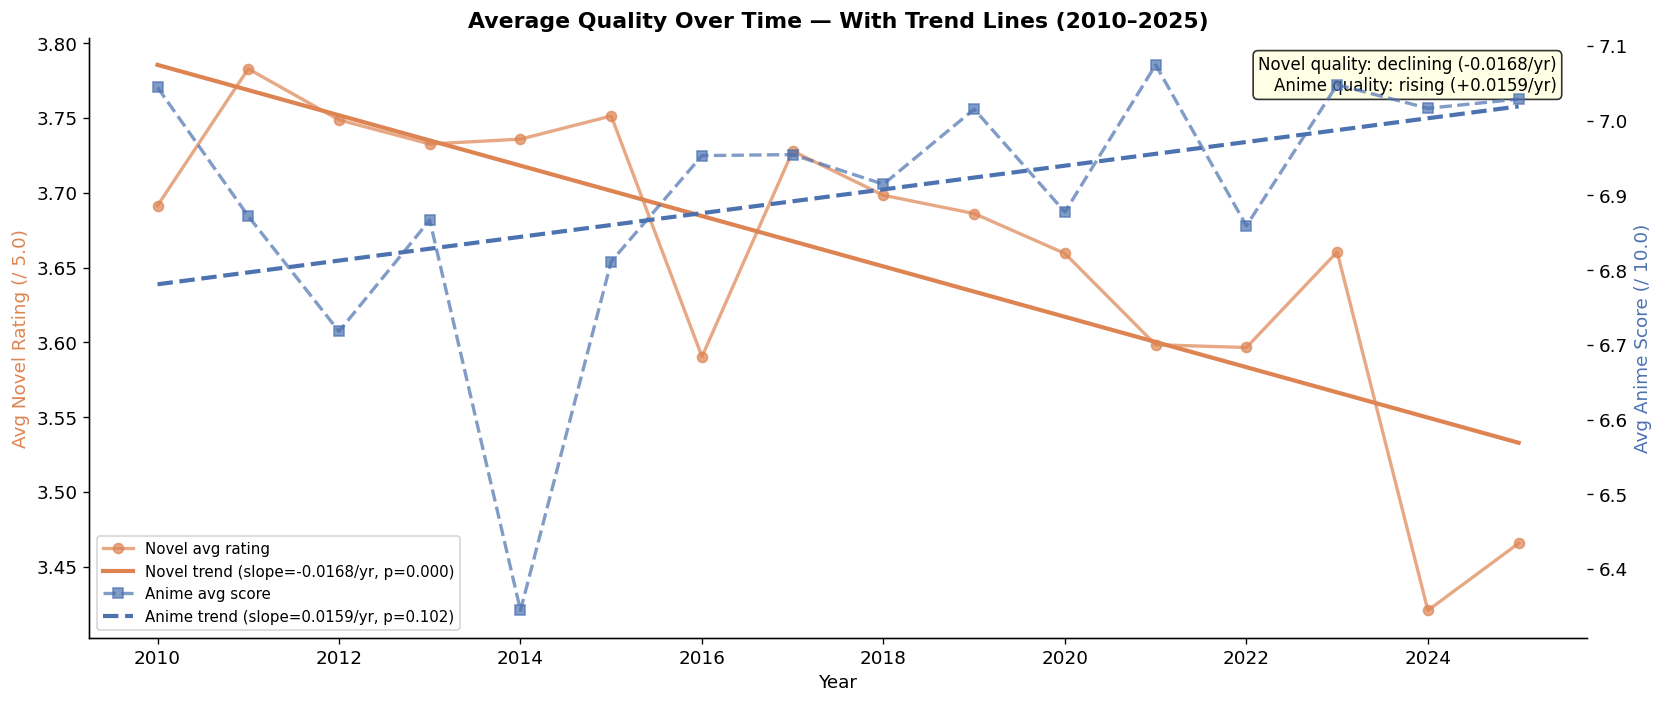

Novel quality trend:  slope=-0.0168/yr | r²=0.612 | p=0.0003
Anime quality trend:  slope=0.0159/yr | r²=0.180 | p=0.1016


In [21]:
# ── Quality over time WITH regression lines ────────────────────────────────
# This is the KEY chart — shows diverging quality trajectories

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# Plot raw lines
ax1.plot(novel_by_year['year'], novel_by_year['avg_rating'],
         color=NOVEL_COLOR, marker='o', linewidth=2, alpha=0.7, label='Novel avg rating')
ax2.plot(anime_by_year['year'], anime_by_year['avg_score'],
         color=ANIME_COLOR, marker='s', linewidth=2, alpha=0.7, linestyle='--', label='Anime avg score')

# Novel regression line
n_slope, n_intercept, n_r, n_p, _ = stats.linregress(novel_by_year['year'], novel_by_year['avg_rating'])
n_trend = n_slope * novel_by_year['year'] + n_intercept
ax1.plot(novel_by_year['year'], n_trend, color=NOVEL_COLOR, linewidth=2.5,
         linestyle='-', label=f'Novel trend (slope={n_slope:.4f}/yr, p={n_p:.3f})')

# Anime regression line
a_slope, a_intercept, a_r, a_p, _ = stats.linregress(anime_by_year['year'], anime_by_year['avg_score'])
a_trend = a_slope * anime_by_year['year'] + a_intercept
ax2.plot(anime_by_year['year'], a_trend, color=ANIME_COLOR, linewidth=2.5,
         linestyle='--', label=f'Anime trend (slope={a_slope:.4f}/yr, p={a_p:.3f})')

ax1.set_title('Average Quality Over Time — With Trend Lines (2010–2025)', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Novel Rating (/ 5.0)', color=NOVEL_COLOR)
ax2.set_ylabel('Avg Anime Score (/ 10.0)', color=ANIME_COLOR)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(2))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=9)

# Annotation box
ax1.text(0.98, 0.97,
         f'Novel quality: declining ({n_slope:.4f}/yr)\nAnime quality: rising ({a_slope:+.4f}/yr)',
         transform=ax1.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('03_quality_over_time_regression.png', bbox_inches='tight')
plt.show()

print(f'Novel quality trend:  slope={n_slope:.4f}/yr | r²={n_r**2:.3f} | p={n_p:.4f}')
print(f'Anime quality trend:  slope={a_slope:.4f}/yr | r²={a_r**2:.3f} | p={a_p:.4f}')

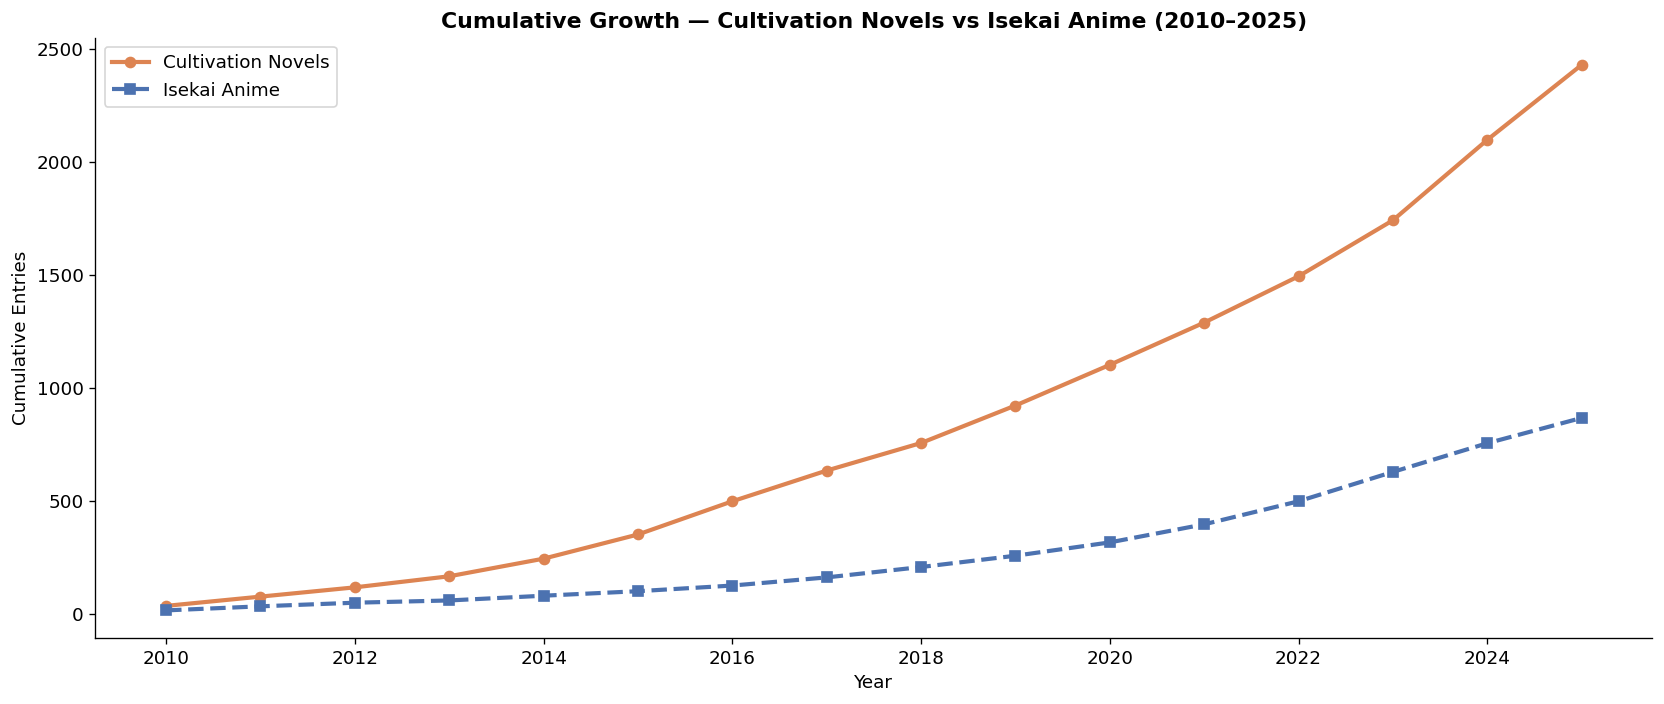

In [22]:
# ── Cumulative growth ──────────────────────────────────────────────────────
novel_by_year['cumulative'] = novel_by_year['count'].cumsum()
anime_by_year['cumulative']  = anime_by_year['count'].cumsum()

plt.figure(figsize=(14, 6))
plt.plot(novel_by_year['year'], novel_by_year['cumulative'],
         color=NOVEL_COLOR, linewidth=2.5, marker='o', label='Cultivation Novels')
plt.plot(anime_by_year['year'], anime_by_year['cumulative'],
         color=ANIME_COLOR, linewidth=2.5, marker='s', linestyle='--', label='Isekai Anime')
plt.title('Cumulative Growth — Cultivation Novels vs Isekai Anime (2010–2025)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Cumulative Entries')
plt.legend()
plt.tight_layout()
plt.savefig('04_cumulative_growth.png', bbox_inches='tight')
plt.show()

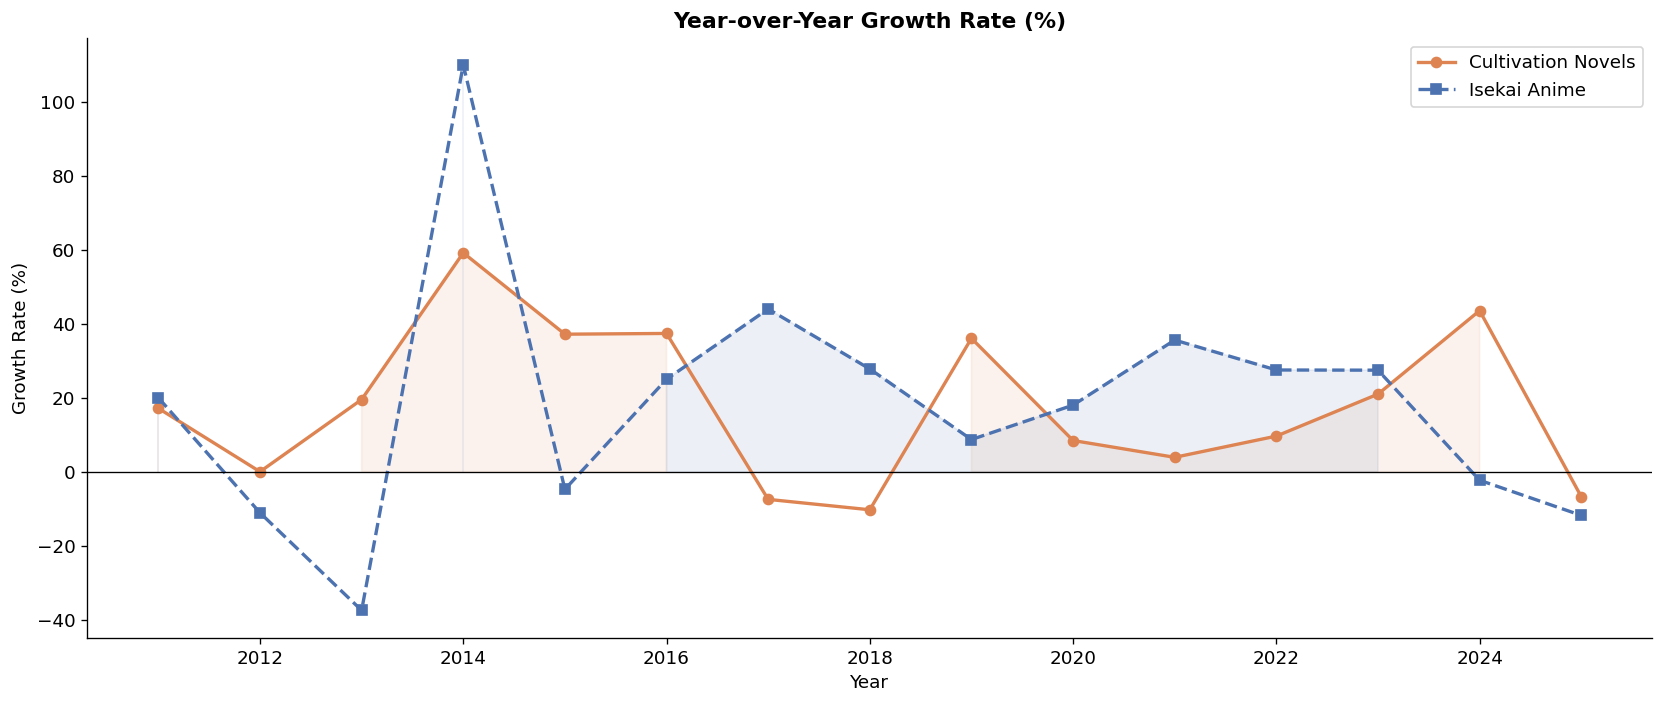

In [23]:
# ── Year-over-year growth rate ─────────────────────────────────────────────
novel_by_year['yoy_growth'] = novel_by_year['count'].pct_change() * 100
anime_by_year['yoy_growth']  = anime_by_year['count'].pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(novel_by_year['year'], novel_by_year['yoy_growth'],
        color=NOVEL_COLOR, linewidth=2, marker='o', label='Cultivation Novels')
ax.plot(anime_by_year['year'], anime_by_year['yoy_growth'],
        color=ANIME_COLOR, linewidth=2, marker='s', linestyle='--', label='Isekai Anime')
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(novel_by_year['year'], novel_by_year['yoy_growth'], 0,
                where=novel_by_year['yoy_growth'] > 0, alpha=0.1, color=NOVEL_COLOR)
ax.fill_between(anime_by_year['year'], anime_by_year['yoy_growth'], 0,
                where=anime_by_year['yoy_growth'] > 0, alpha=0.1, color=ANIME_COLOR)
ax.set_title('Year-over-Year Growth Rate (%)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Growth Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('05_yoy_growth.png', bbox_inches='tight')
plt.show()

## 4. Part 2 — Saturation Markers

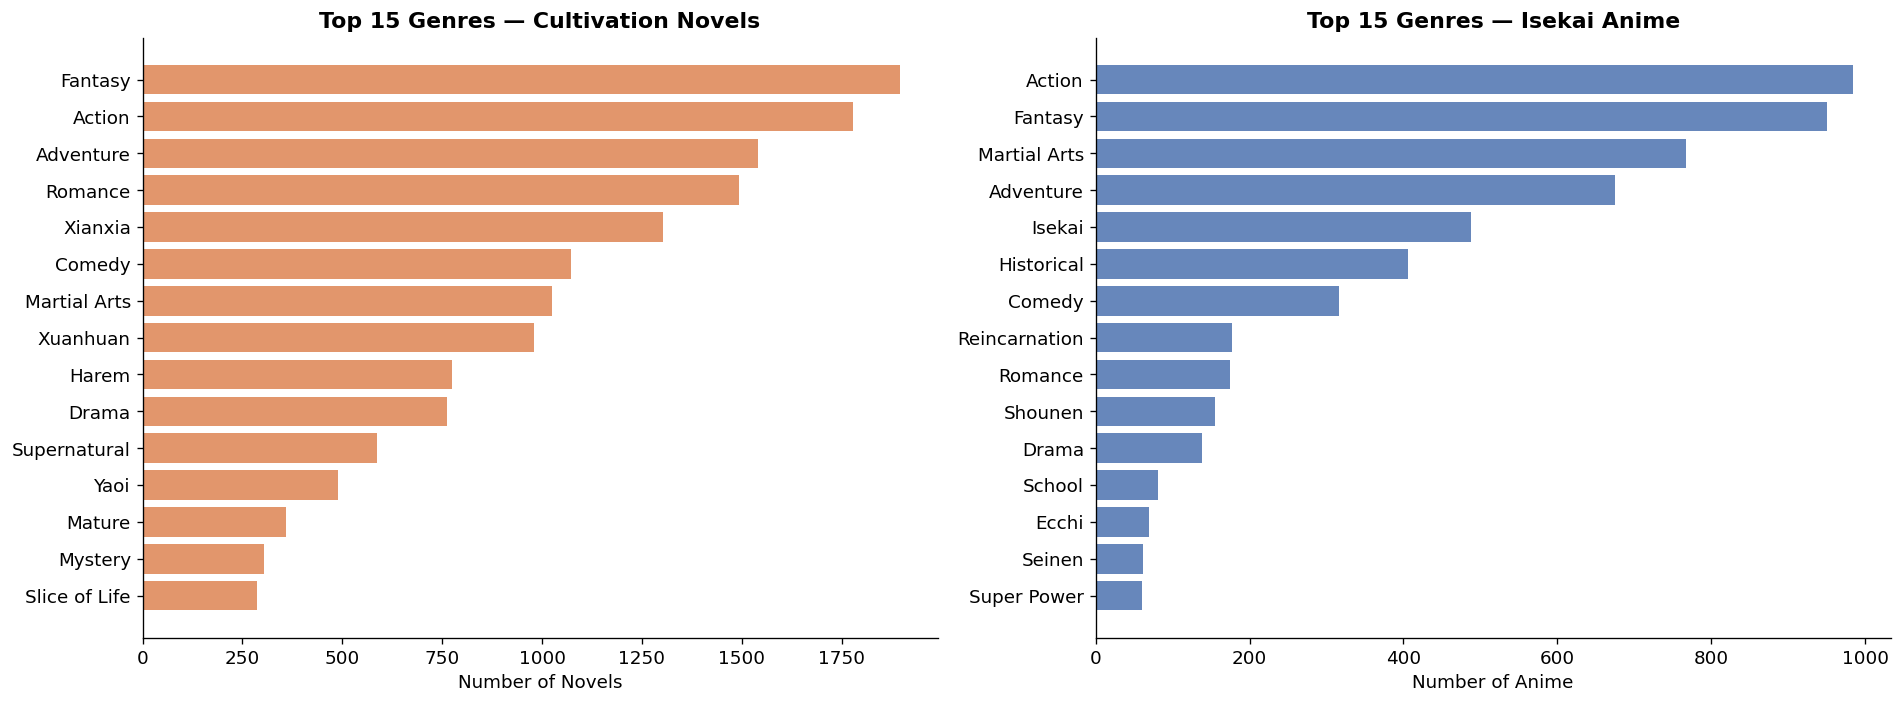

In [24]:
# ── Top genres ─────────────────────────────────────────────────────────────
# Filter junction tables to rated novels only
rated_novel_ids = set(novels['id'].tolist())
novel_genres_rated = novel_genres_df[novel_genres_df['novel_id'].isin(rated_novel_ids)]
novel_tags_rated   = novel_tags_df[novel_tags_df['novel_id'].isin(rated_novel_ids)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_novel_genres = novel_genres_rated['genre'].value_counts().head(15)
axes[0].barh(top_novel_genres.index[::-1], top_novel_genres.values[::-1], color=NOVEL_COLOR, alpha=0.85)
axes[0].set_title('Top 15 Genres — Cultivation Novels', fontweight='bold')
axes[0].set_xlabel('Number of Novels')

top_anime_genres = anime_genres_df['genre'].value_counts().head(15)
axes[1].barh(top_anime_genres.index[::-1], top_anime_genres.values[::-1], color=ANIME_COLOR, alpha=0.85)
axes[1].set_title('Top 15 Genres — Isekai Anime', fontweight='bold')
axes[1].set_xlabel('Number of Anime')

plt.tight_layout()
plt.savefig('06_top_genres.png', bbox_inches='tight')
plt.show()

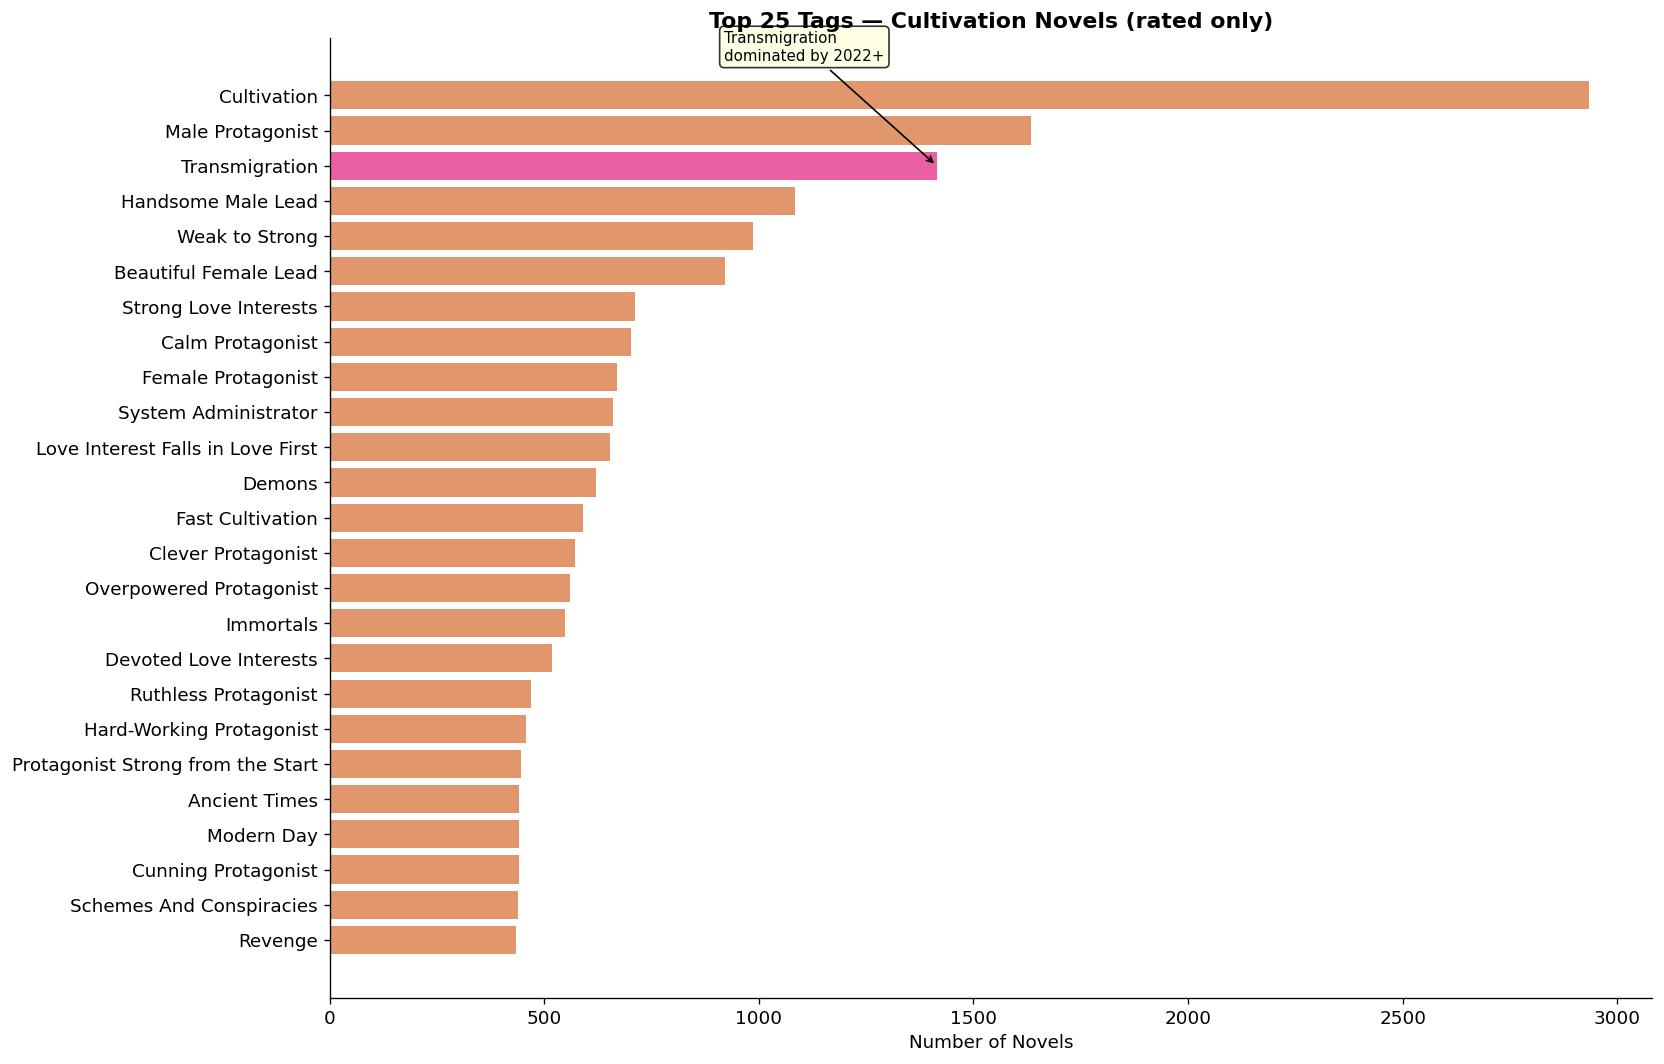

In [25]:
# ── Top tags with transmigration explosion annotated ──────────────────────
top_tags = novel_tags_rated['tag'].value_counts().head(25)

fig, ax = plt.subplots(figsize=(14, 9))
colors = [NOVEL_COLOR if t != 'Transmigration' else '#E84393' for t in top_tags.index[::-1]]
bars = ax.barh(top_tags.index[::-1], top_tags.values[::-1], color=colors, alpha=0.85)

# Annotate transmigration bar
transm_val = top_tags.get('Transmigration', 0)
if transm_val:
    ax.annotate('Transmigration\ndominated by 2022+',
                xy=(transm_val, list(top_tags.index[::-1]).index('Transmigration')),
                xytext=(transm_val * 0.65, list(top_tags.index[::-1]).index('Transmigration') + 3),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=9, color='black',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.set_title('Top 25 Tags — Cultivation Novels (rated only)', fontweight='bold')
ax.set_xlabel('Number of Novels')
plt.tight_layout()
plt.savefig('07_top_tags.png', bbox_inches='tight')
plt.show()

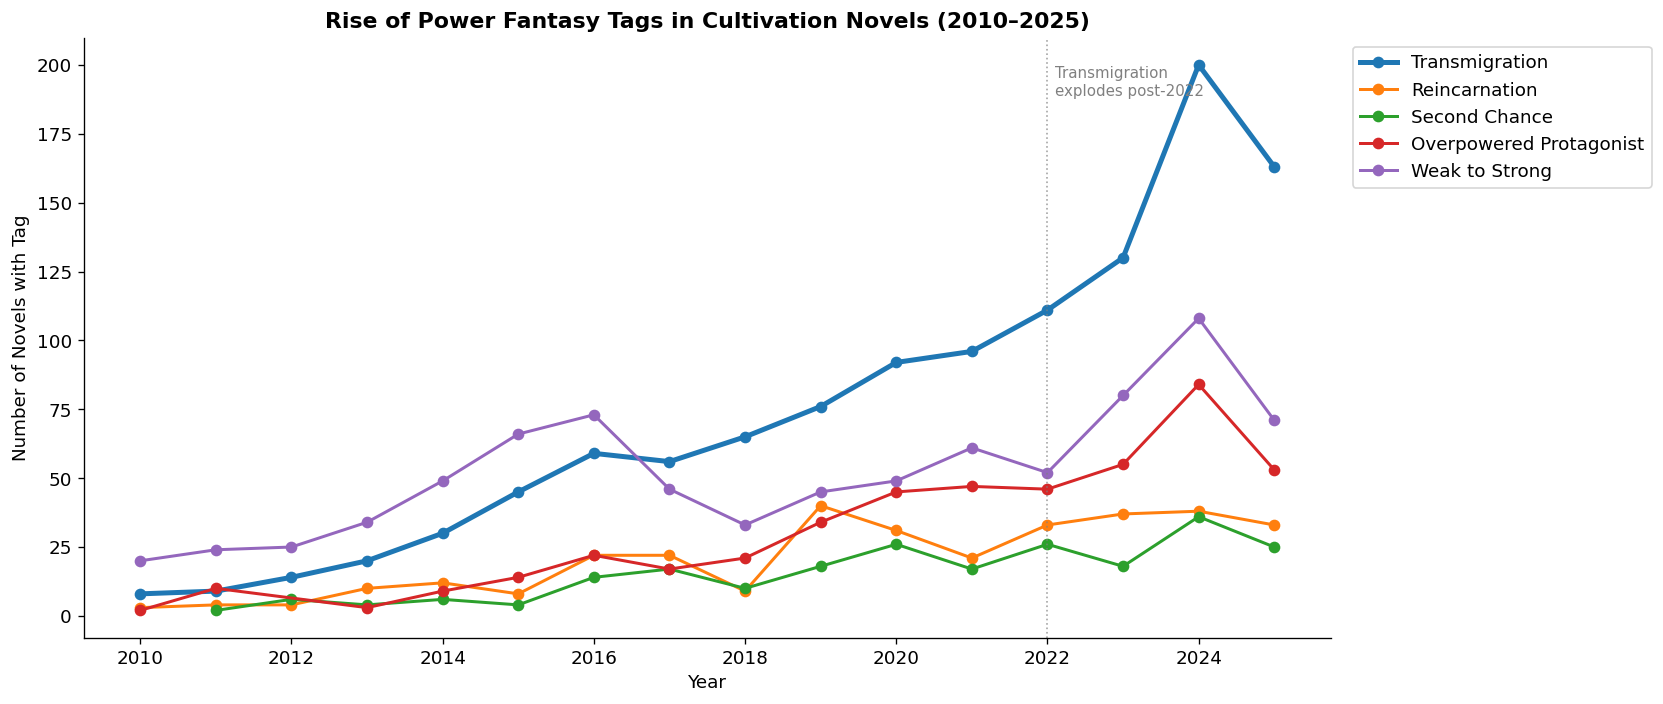

In [26]:
# ── Power fantasy tag trends over time ────────────────────────────────────
POWER_TAGS = ['Transmigration', 'Reincarnation', 'Second Chance',
              'Overpowered Protagonist', 'Weak to Strong']

novels_with_year = novels[['id', 'year']].dropna(subset=['year'])
tag_novel = novel_tags_rated.merge(novels_with_year, left_on='novel_id', right_on='id')
tag_novel = tag_novel[tag_novel['tag'].isin(POWER_TAGS)]
tag_novel = tag_novel[tag_novel['year'].between(2010, 2025)]
tag_by_year = tag_novel.groupby(['year', 'tag']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 6))
for tag in POWER_TAGS:
    data = tag_by_year[tag_by_year['tag'] == tag]
    if not data.empty:
        lw = 3 if tag == 'Transmigration' else 1.8
        ax.plot(data['year'], data['count'], marker='o', linewidth=lw, label=tag)

# Annotate the 2022 explosion
ax.axvline(2022, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(2022.1, ax.get_ylim()[1] * 0.9, 'Transmigration\nexplodes post-2022',
        fontsize=9, color='gray')

ax.set_title('Rise of Power Fantasy Tags in Cultivation Novels (2010–2025)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Novels with Tag')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('08_power_fantasy_tags.png', bbox_inches='tight')
plt.show()

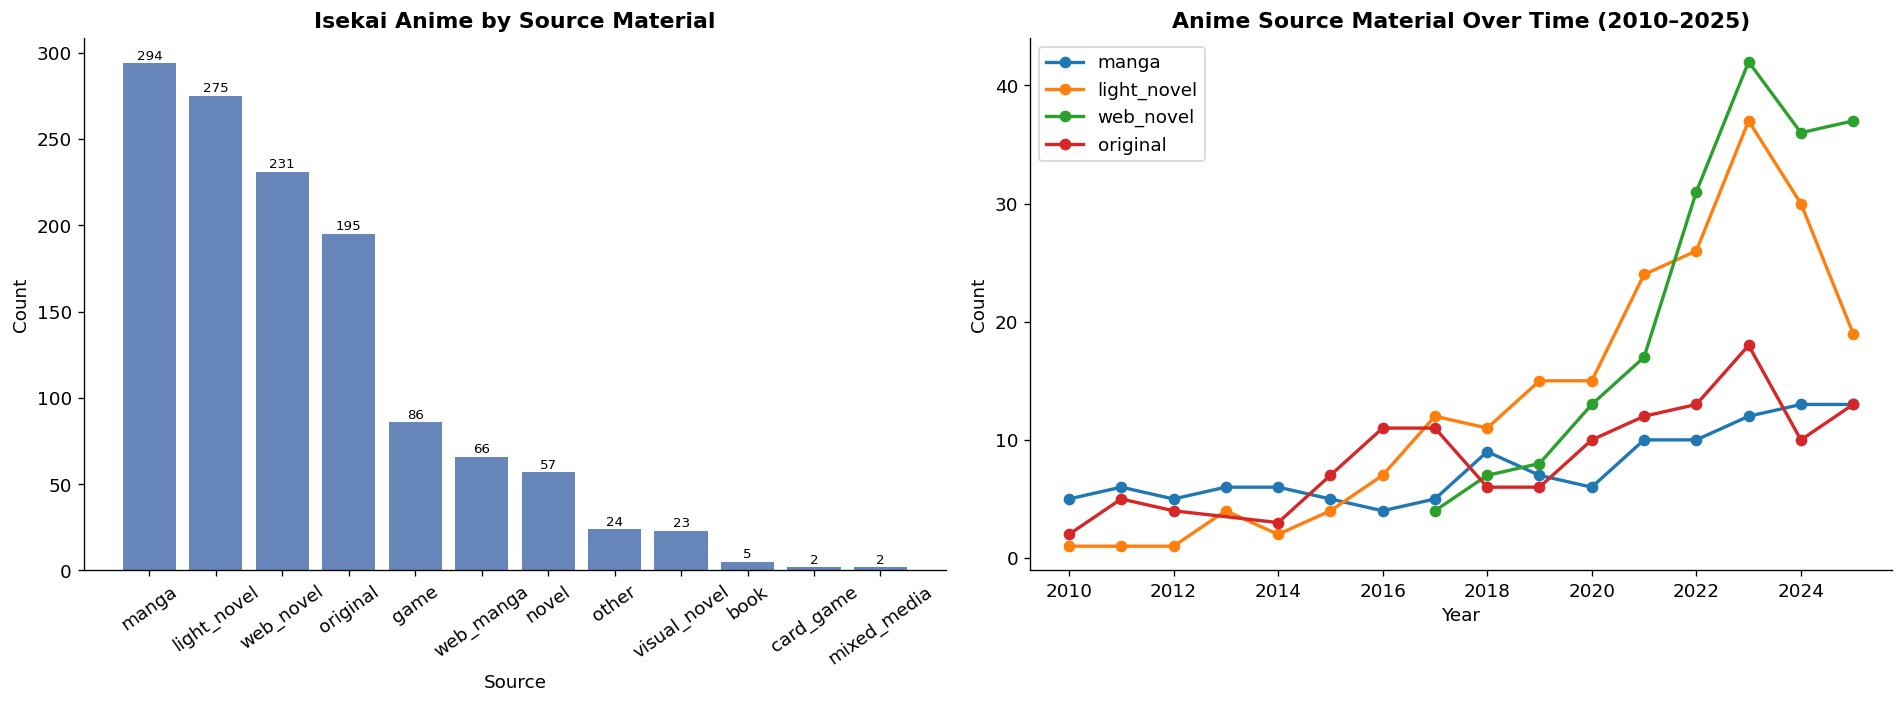

In [27]:
# ── Source material breakdown and trend ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

source_counts = anime['source'].value_counts().dropna()
bars = axes[0].bar(source_counts.index, source_counts.values, color=ANIME_COLOR, alpha=0.85)
axes[0].set_title('Isekai Anime by Source Material', fontweight='bold')
axes[0].set_xlabel('Source')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)
for bar, val in zip(bars, source_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=8)

top_sources = source_counts.head(4).index.tolist()
source_by_year = anime.groupby(['start_year', 'source']).size().reset_index(name='count')
source_by_year = source_by_year[
    source_by_year['start_year'].between(2010, 2025) &
    source_by_year['source'].isin(top_sources)
]
for source in top_sources:
    data = source_by_year[source_by_year['source'] == source]
    if not data.empty:
        axes[1].plot(data['start_year'], data['count'], marker='o', linewidth=2, label=source)

axes[1].set_title('Anime Source Material Over Time (2010–2025)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('09_source_material.png', bbox_inches='tight')
plt.show()

## 5. Part 3 — Quality vs Popularity

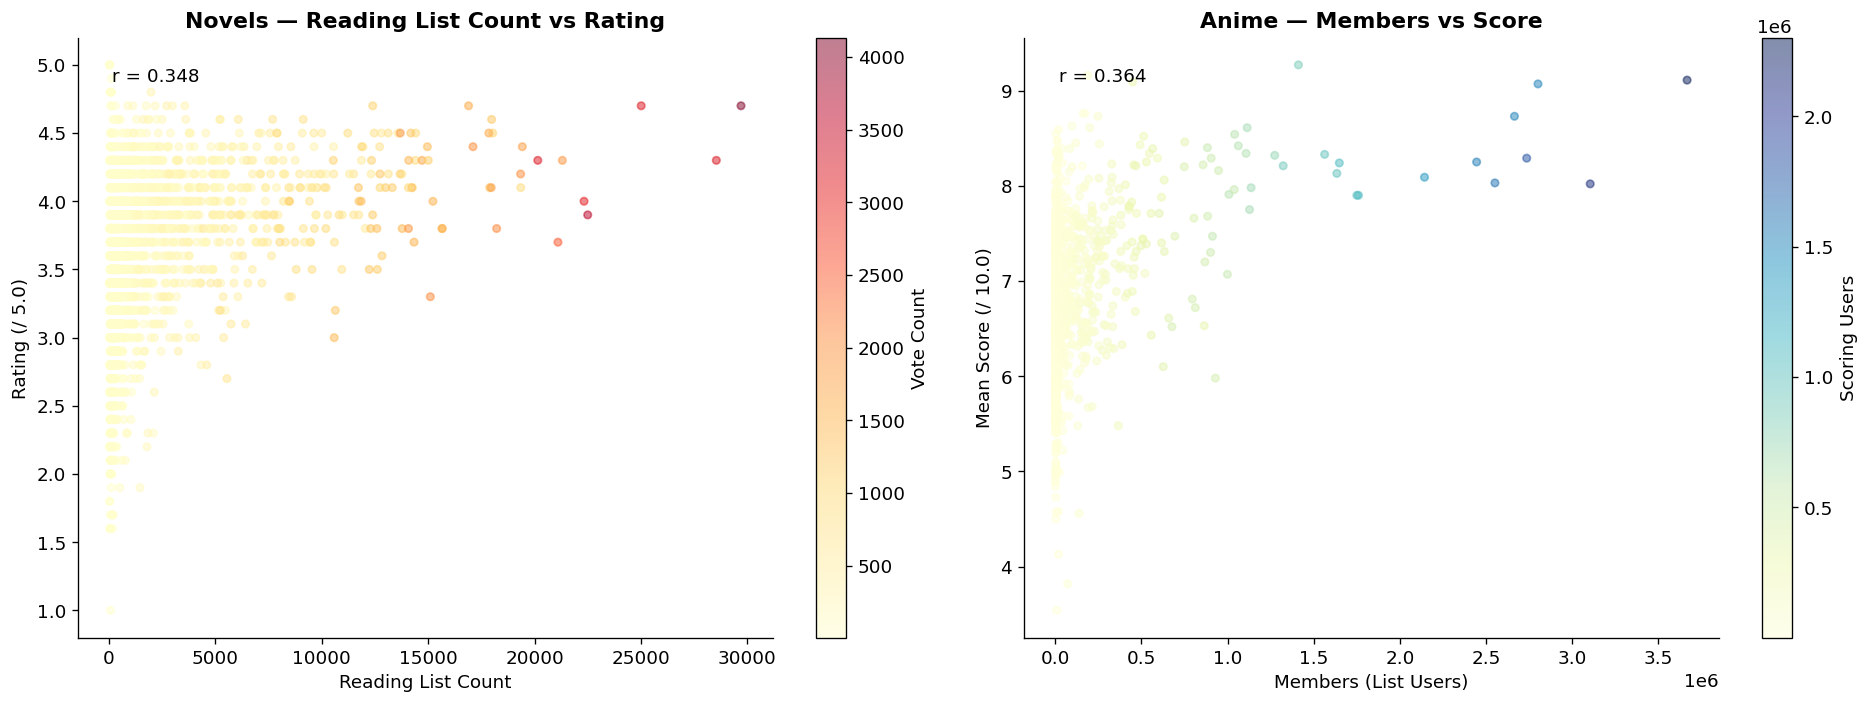

Novel popularity-quality correlation: 0.348
Anime popularity-quality correlation: 0.364


In [28]:
# ── Popularity vs Quality scatter ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

novel_sc = novels.dropna(subset=['rating', 'reading_list_count', 'vote_count'])
sc1 = axes[0].scatter(novel_sc['reading_list_count'], novel_sc['rating'],
                      c=novel_sc['vote_count'], cmap='YlOrRd', alpha=0.5, s=20)
plt.colorbar(sc1, ax=axes[0], label='Vote Count')
corr_n = novel_sc['reading_list_count'].corr(novel_sc['rating'])
axes[0].set_title('Novels — Reading List Count vs Rating', fontweight='bold')
axes[0].set_xlabel('Reading List Count')
axes[0].set_ylabel('Rating (/ 5.0)')
axes[0].text(0.05, 0.95, f'r = {corr_n:.3f}', transform=axes[0].transAxes,
             fontsize=11, verticalalignment='top')

anime_sc = anime.dropna(subset=['mean', 'members', 'num_scoring_users'])
anime_sc = anime_sc[anime_sc['num_scoring_users'] >= 100]
sc2 = axes[1].scatter(anime_sc['members'], anime_sc['mean'],
                      c=anime_sc['num_scoring_users'], cmap='YlGnBu', alpha=0.5, s=20)
plt.colorbar(sc2, ax=axes[1], label='Scoring Users')
corr_a = anime_sc['members'].corr(anime_sc['mean'])
axes[1].set_title('Anime — Members vs Score', fontweight='bold')
axes[1].set_xlabel('Members (List Users)')
axes[1].set_ylabel('Mean Score (/ 10.0)')
axes[1].text(0.05, 0.95, f'r = {corr_a:.3f}', transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top')

plt.tight_layout()
plt.savefig('10_popularity_vs_quality.png', bbox_inches='tight')
plt.show()
print(f'Novel popularity-quality correlation: {corr_n:.3f}')
print(f'Anime popularity-quality correlation: {corr_a:.3f}')

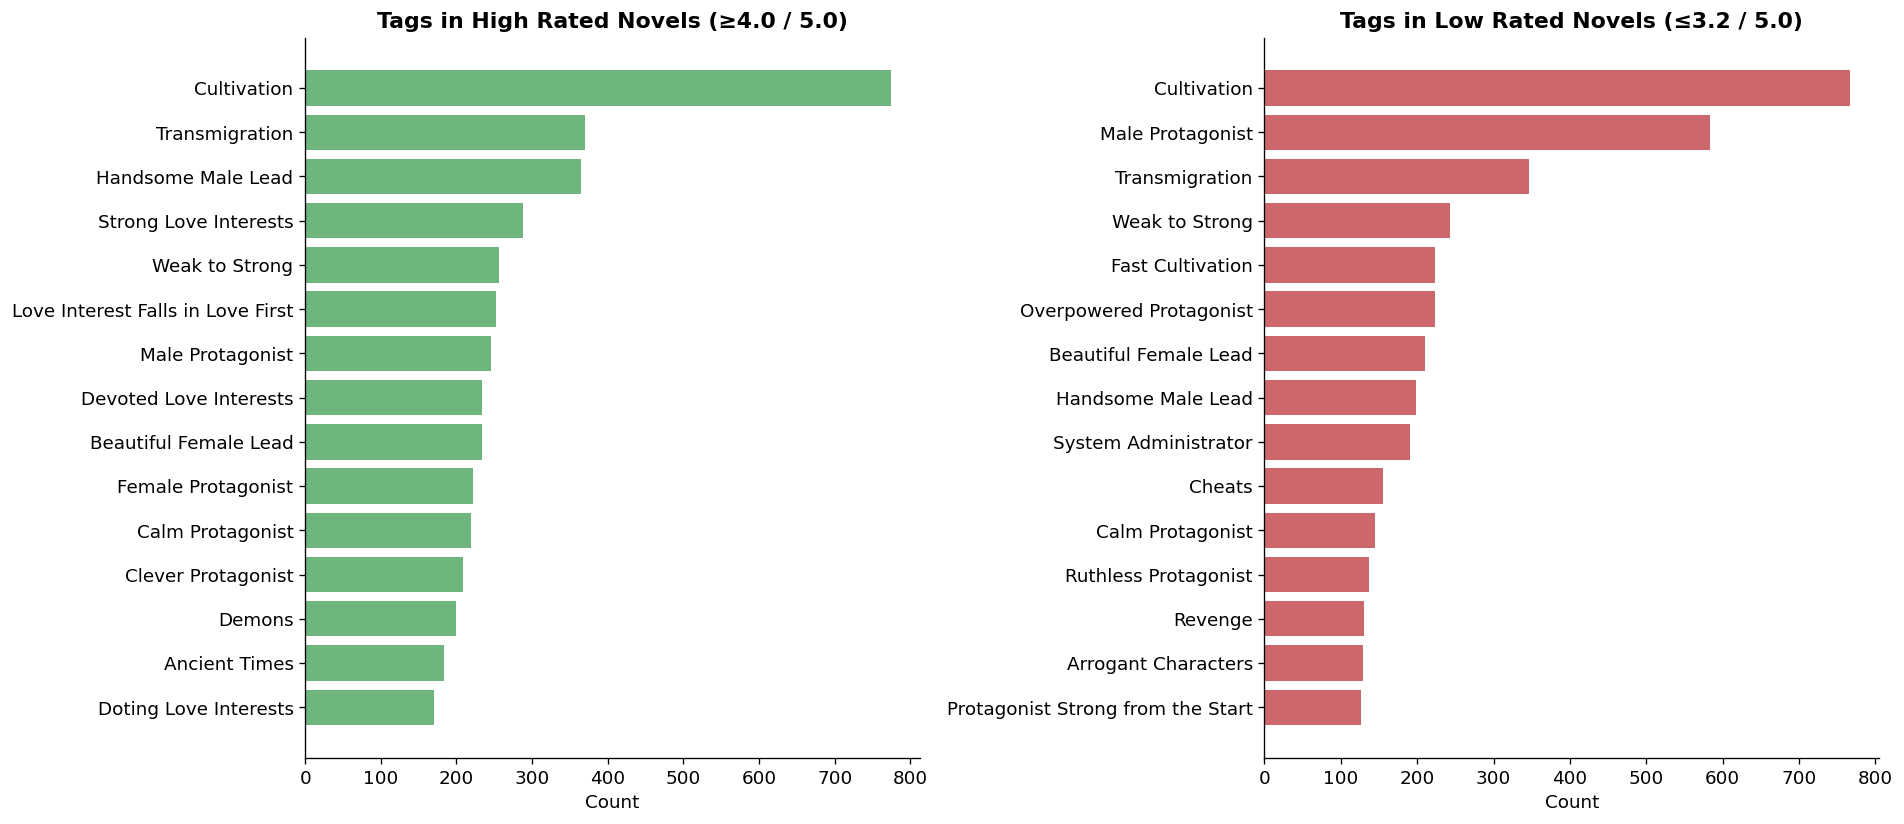

Tags appearing in low-rated but NOT high-rated top 15: {'System Administrator', 'Protagonist Strong from the Start', 'Arrogant Characters', 'Revenge', 'Ruthless Protagonist', 'Fast Cultivation', 'Cheats', 'Overpowered Protagonist'}


In [29]:
# ── Tags in high vs low rated novels ─────────────────────────────────────
HIGH_T = novels['rating'].quantile(0.75)
LOW_T  = novels['rating'].quantile(0.25)

high_ids = set(novels[novels['rating'] >= HIGH_T]['id'].tolist())
low_ids  = set(novels[novels['rating'] <= LOW_T]['id'].tolist())

high_tags = novel_tags_rated[novel_tags_rated['novel_id'].isin(high_ids)]['tag'].value_counts().head(15)
low_tags  = novel_tags_rated[novel_tags_rated['novel_id'].isin(low_ids)]['tag'].value_counts().head(15)

# Tags that appear DISPROPORTIONATELY in low-rated novels
all_tag_counts = novel_tags_rated['tag'].value_counts()
high_pct = (high_tags / len(high_ids) * 100)
low_pct  = (low_tags  / len(low_ids)  * 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(high_tags.index[::-1], high_tags.values[::-1], color=ACCENT_COLOR, alpha=0.85)
axes[0].set_title(f'Tags in High Rated Novels (≥{HIGH_T:.1f} / 5.0)', fontweight='bold')
axes[0].set_xlabel('Count')

axes[1].barh(low_tags.index[::-1], low_tags.values[::-1], color=BAD_COLOR, alpha=0.85)
axes[1].set_title(f'Tags in Low Rated Novels (≤{LOW_T:.1f} / 5.0)', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('11_high_vs_low_tags.png', bbox_inches='tight')
plt.show()

# Tags that uniquely predict low ratings
low_only = set(low_tags.index) - set(high_tags.index)
print(f'Tags appearing in low-rated but NOT high-rated top 15: {low_only}')

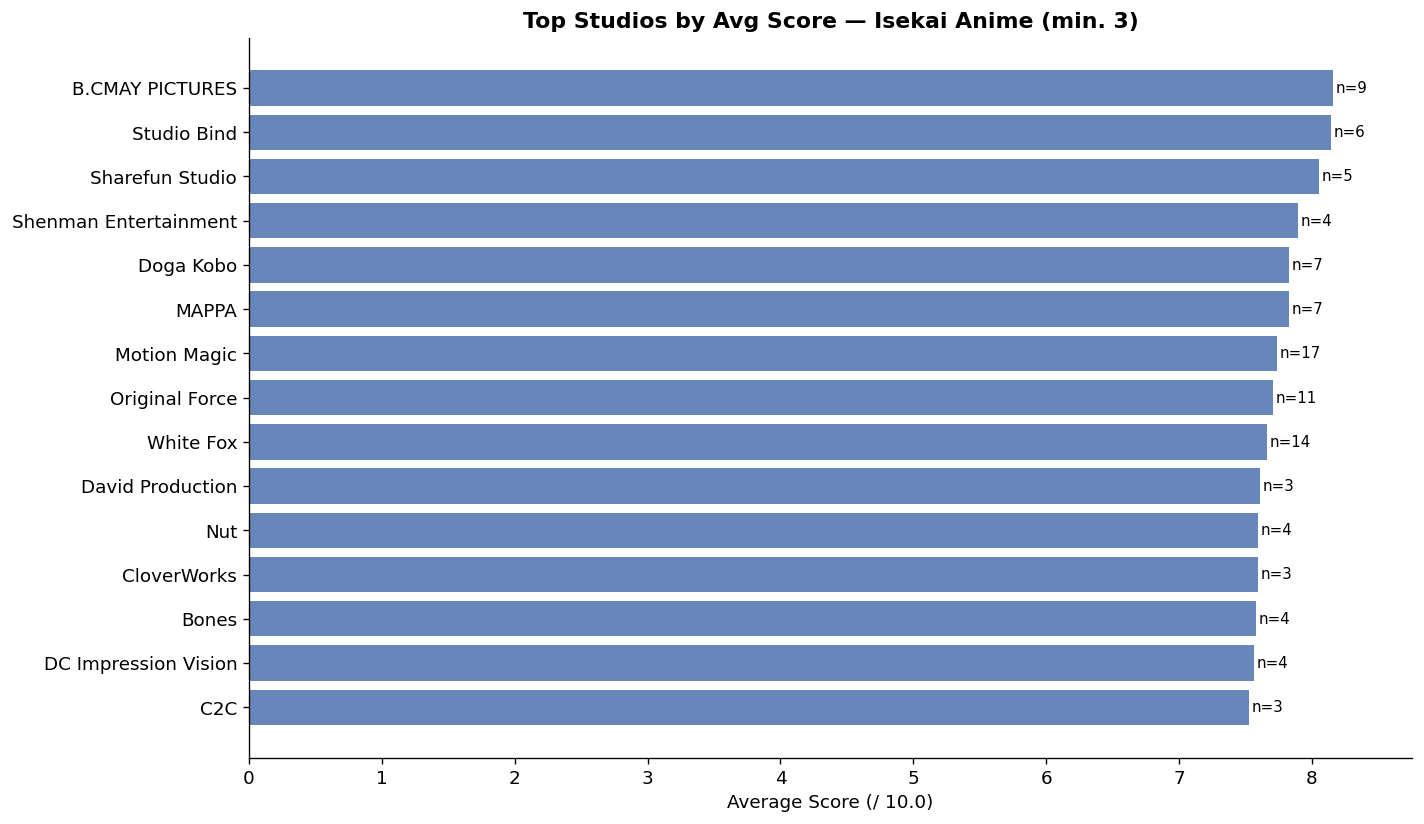

In [30]:
# ── Studio quality ranking ─────────────────────────────────────────────────
studio_anime = anime_studios_df.merge(anime[['id', 'mean']], left_on='anime_id', right_on='id')
studio_stats = studio_anime.groupby('studio').agg(
    count=('mean', 'count'), avg_score=('mean', 'mean')
).reset_index()
studio_stats = studio_stats[studio_stats['count'] >= 3].sort_values('avg_score', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(studio_stats['studio'][::-1], studio_stats['avg_score'][::-1],
               color=ANIME_COLOR, alpha=0.85)
for bar, count in zip(bars, studio_stats['count'][::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'n={count}', va='center', fontsize=9)
ax.set_title('Top Studios by Avg Score — Isekai Anime (min. 3)', fontweight='bold')
ax.set_xlabel('Average Score (/ 10.0)')
ax.set_xlim(0, studio_stats['avg_score'].max() + 0.6)
plt.tight_layout()
plt.savefig('12_top_studios.png', bbox_inches='tight')
plt.show()

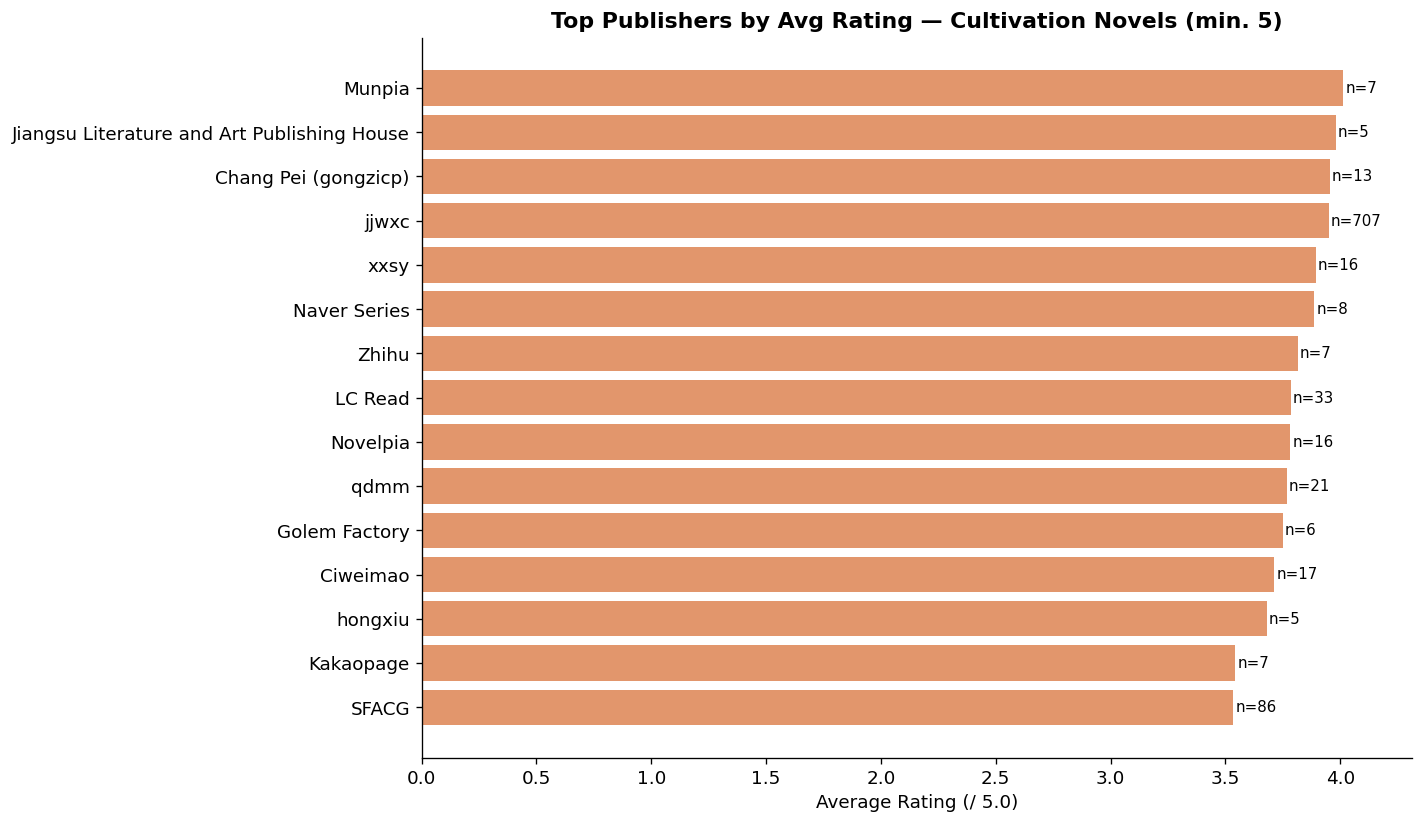

In [31]:
# ── Publisher quality ranking ──────────────────────────────────────────────
pub_novel = novel_publishers_df[novel_publishers_df['novel_id'].isin(rated_novel_ids)].merge(
    novels[['id', 'rating']], left_on='novel_id', right_on='id'
)
pub_stats = pub_novel.groupby('publisher').agg(
    count=('rating', 'count'), avg_rating=('rating', 'mean')
).reset_index()
pub_stats = pub_stats[pub_stats['count'] >= 5].sort_values('avg_rating', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(pub_stats['publisher'][::-1], pub_stats['avg_rating'][::-1],
               color=NOVEL_COLOR, alpha=0.85)
for bar, count in zip(bars, pub_stats['count'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'n={count}', va='center', fontsize=9)
ax.set_title('Top Publishers by Avg Rating — Cultivation Novels (min. 5)', fontweight='bold')
ax.set_xlabel('Average Rating (/ 5.0)')
ax.set_xlim(0, pub_stats['avg_rating'].max() + 0.3)
plt.tight_layout()
plt.savefig('13_top_publishers.png', bbox_inches='tight')
plt.show()

## 6. Part 4 — Cross-Dataset Comparison

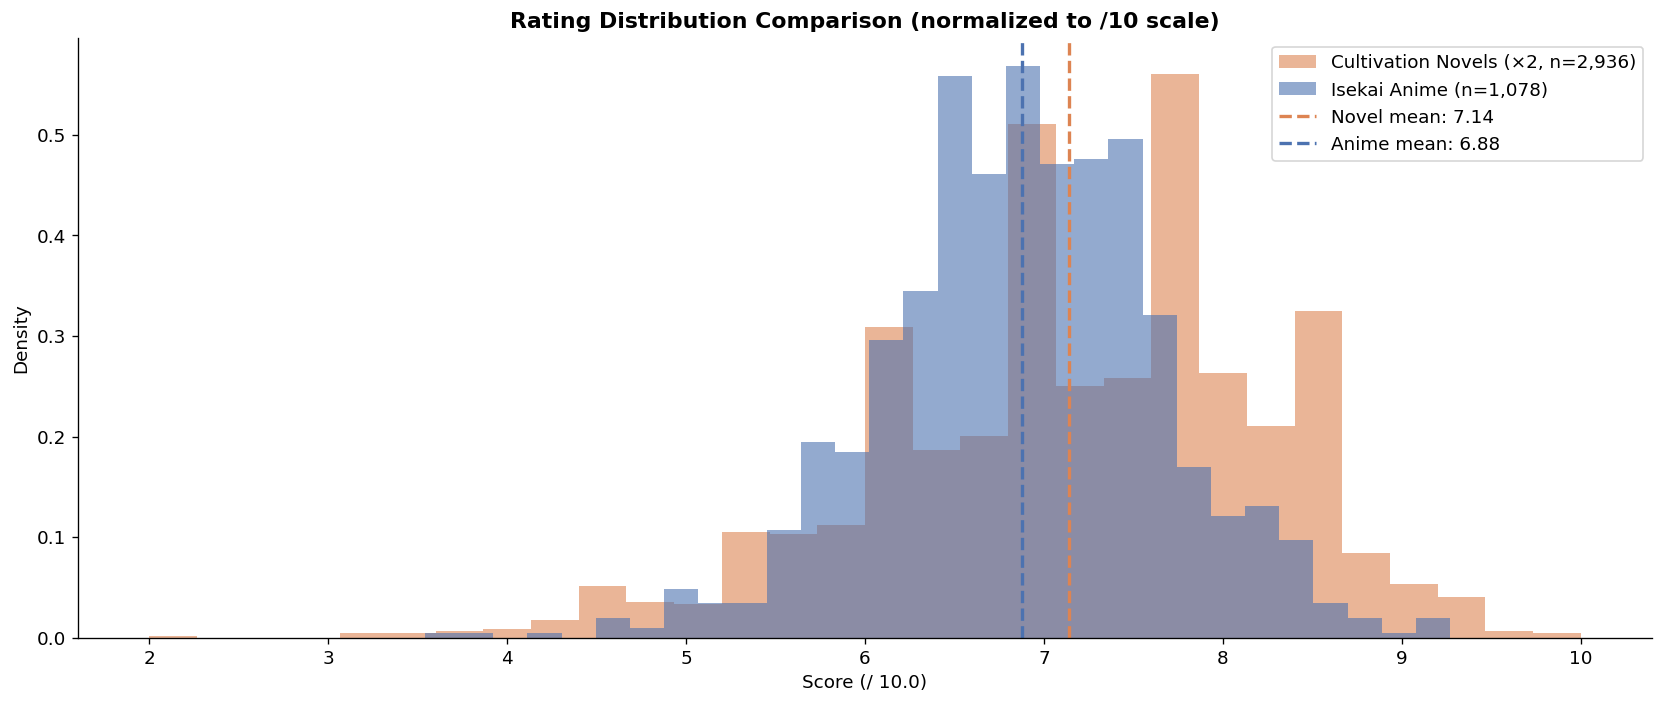

KS test — statistic: 0.2499, p-value: 0.000000
Distributions are statistically different.


In [32]:
# ── Normalized rating comparison ──────────────────────────────────────────
novel_scaled = novels['rating'].dropna() * 2
anime_rated  = anime['mean'].dropna()

plt.figure(figsize=(14, 6))
plt.hist(novel_scaled, bins=30, alpha=0.6, color=NOVEL_COLOR,
         label=f'Cultivation Novels (×2, n={len(novel_scaled):,})', density=True)
plt.hist(anime_rated, bins=30, alpha=0.6, color=ANIME_COLOR,
         label=f'Isekai Anime (n={len(anime_rated):,})', density=True)
plt.axvline(novel_scaled.mean(), color=NOVEL_COLOR, linestyle='--', linewidth=2,
            label=f'Novel mean: {novel_scaled.mean():.2f}')
plt.axvline(anime_rated.mean(), color=ANIME_COLOR, linestyle='--', linewidth=2,
            label=f'Anime mean: {anime_rated.mean():.2f}')
plt.title('Rating Distribution Comparison (normalized to /10 scale)', fontweight='bold')
plt.xlabel('Score (/ 10.0)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('14_rating_comparison.png', bbox_inches='tight')
plt.show()

# Statistical test — are distributions significantly different?
ks_stat, ks_p = stats.ks_2samp(novel_scaled.dropna(), anime_rated.dropna())
print(f'KS test — statistic: {ks_stat:.4f}, p-value: {ks_p:.6f}')
print('Distributions are statistically different.' if ks_p < 0.05 else 'No significant difference.')

Genres in novels only:  13
Genres in anime only:   49
Shared genres:          22


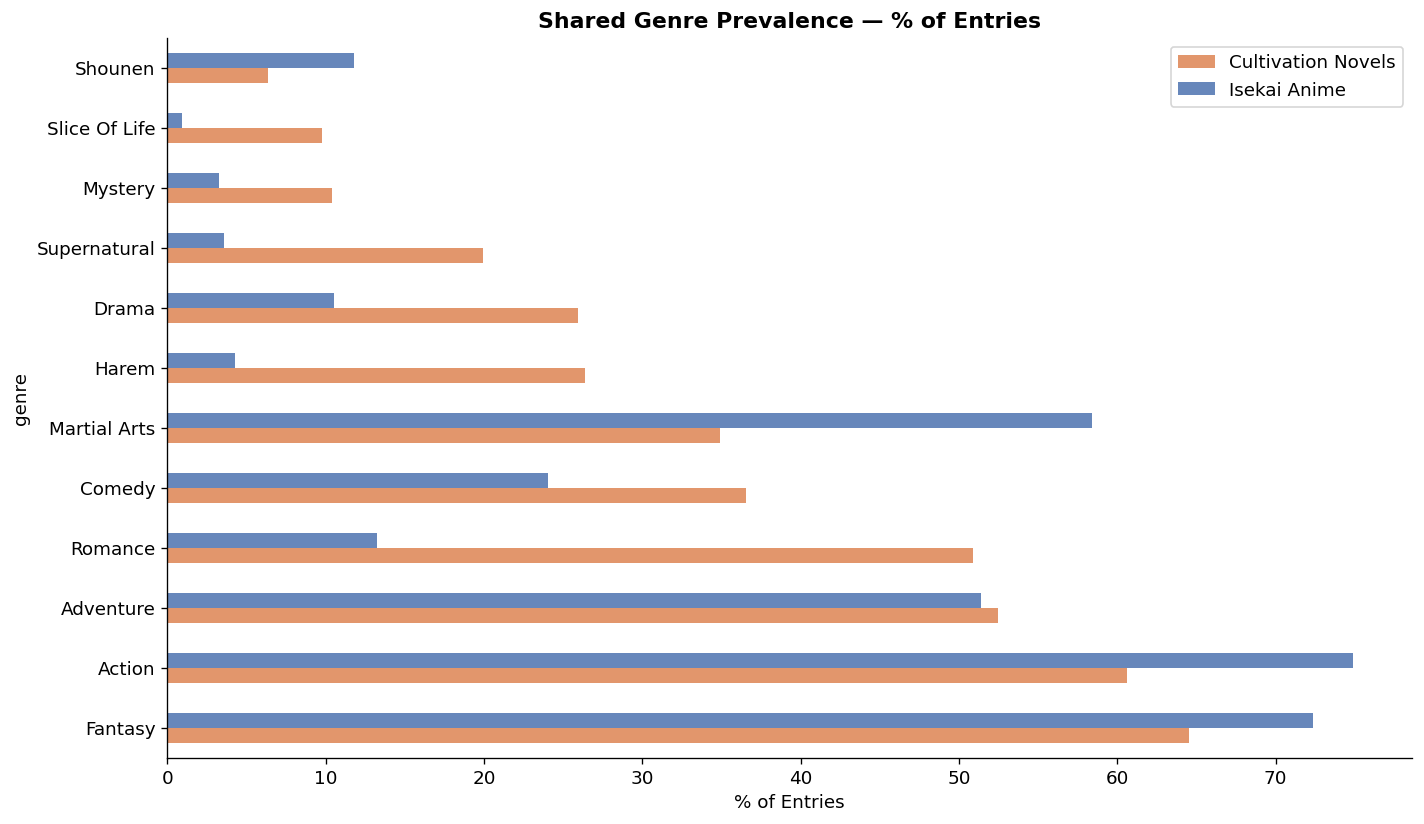

In [33]:
# ── Shared genre prevalence ────────────────────────────────────────────────
novel_genre_set = set(novel_genres_rated['genre'].str.lower().unique())
anime_genre_set = set(anime_genres_df['genre'].str.lower().unique())
shared_genres   = novel_genre_set & anime_genre_set

print(f'Genres in novels only:  {len(novel_genre_set - anime_genre_set)}')
print(f'Genres in anime only:   {len(anime_genre_set - novel_genre_set)}')
print(f'Shared genres:          {len(shared_genres)}')

shared_list = list(shared_genres)
novel_shared_pct = (novel_genres_rated[novel_genres_rated['genre'].str.lower().isin(shared_list)]
                    ['genre'].str.title().value_counts() / len(novels) * 100)
anime_shared_pct = (anime_genres_df[anime_genres_df['genre'].str.lower().isin(shared_list)]
                    ['genre'].str.title().value_counts() / len(anime) * 100)

comparison = pd.DataFrame({'Novel %': novel_shared_pct, 'Anime %': anime_shared_pct}).dropna()
comparison = comparison.sort_values('Novel %', ascending=False).head(12)

comparison.plot(kind='barh', figsize=(12, 7), color=[NOVEL_COLOR, ANIME_COLOR], alpha=0.85)
plt.title('Shared Genre Prevalence — % of Entries', fontweight='bold')
plt.xlabel('% of Entries')
plt.legend(['Cultivation Novels', 'Isekai Anime'])
plt.tight_layout()
plt.savefig('15_shared_genres.png', bbox_inches='tight')
plt.show()

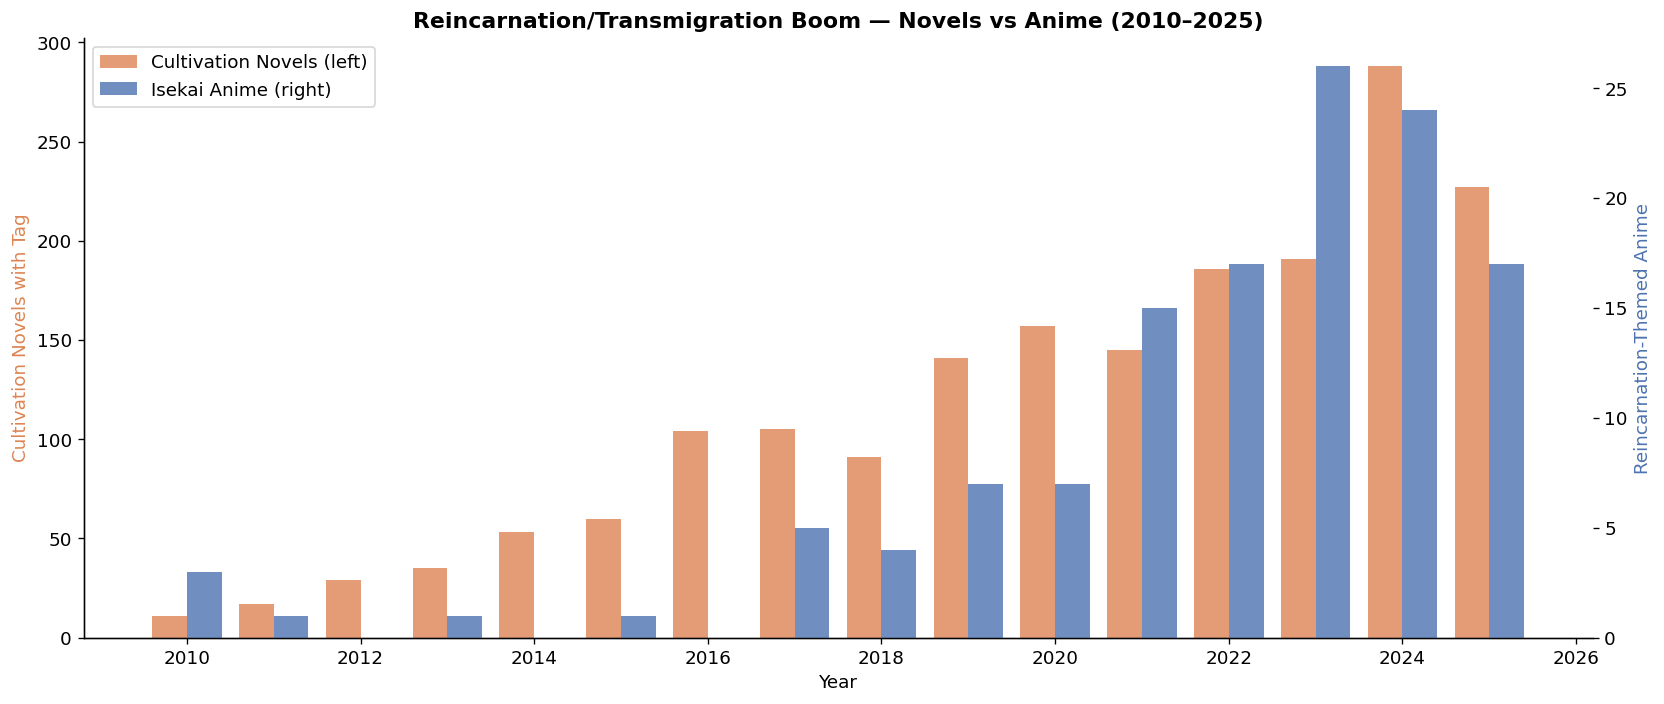

In [34]:
# ── Reincarnation boom side by side ───────────────────────────────────────
REIN_TAGS = ['Transmigration', 'Reincarnation', 'Second Chance', 'Time Travel']

rein_novels = novel_tags_rated[novel_tags_rated['tag'].isin(REIN_TAGS)].merge(
    novels[['id', 'year']], left_on='novel_id', right_on='id'
)
rein_by_year = (rein_novels[rein_novels['year'].between(2010, 2025)]
                .groupby('year').size().reset_index(name='novel_count'))

rein_anime = anime_themes_df[anime_themes_df['theme'] == 'Reincarnation'].merge(
    anime[['id', 'start_year']], left_on='anime_id', right_on='id'
)
rein_anime_by_year = (rein_anime[rein_anime['start_year'].between(2010, 2025)]
                      .groupby('start_year').size().reset_index(name='anime_count')
                      .rename(columns={'start_year': 'year'}))

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.bar(rein_by_year['year'] - 0.2, rein_by_year['novel_count'],
        width=0.4, color=NOVEL_COLOR, alpha=0.8, label='Cultivation Novels (left)')
ax2.bar(rein_anime_by_year['year'] + 0.2, rein_anime_by_year['anime_count'],
        width=0.4, color=ANIME_COLOR, alpha=0.8, label='Isekai Anime (right)')

ax1.set_title('Reincarnation/Transmigration Boom — Novels vs Anime (2010–2025)', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Cultivation Novels with Tag', color=NOVEL_COLOR)
ax2.set_ylabel('Reincarnation-Themed Anime', color=ANIME_COLOR)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.savefig('16_reincarnation_boom.png', bbox_inches='tight')
plt.show()

## 7. Key Findings Summary

In [35]:
print('=' * 65)
print('KEY FINDINGS — Isekai vs Cultivation Analysis')
print('=' * 65)

novel_peak = novel_by_year.loc[novel_by_year['count'].idxmax()]
anime_peak = anime_by_year.loc[anime_by_year['count'].idxmax()]

print(f'\n[VOLUME]')
print(f'  Cultivation novel peak:     {novel_peak["year"]:.0f} ({novel_peak["count"]:.0f} novels)')
print(f'  Isekai anime peak:          {anime_peak["year"]:.0f} ({anime_peak["count"]:.0f} anime)')
print(f'  Both genres still growing — no saturation peak detected yet')

print(f'\n[QUALITY — HEADLINE FINDING]')
print(f'  Novel trend:  {n_slope:.4f} pts/yr (DECLINING, p={n_p:.4f})')
print(f'  Anime trend:  {a_slope:+.4f} pts/yr (RISING, p={a_p:.4f})')
print(f'  ★ Two genres with similar themes show OPPOSITE quality trajectories')

print(f'\n[SATURATION MARKER]')
print(f'  Transmigration tag dominates novels — exploded post-2022')
print(f'  Overpowered Protagonist and Fast Cultivation over-represented in low-rated novels')
top_src = anime["source"].value_counts().index[0]
top_src_pct = anime["source"].value_counts().iloc[0] / len(anime) * 100
print(f'  Top anime source: {top_src} ({top_src_pct:.1f}%)')

print(f'\n[CROSS-DATASET]')
print(f'  Shared genres:              {len(shared_genres)}')
print(f'  Novel popularity-quality r: {corr_n:.3f}')
print(f'  Anime popularity-quality r: {corr_a:.3f}')
print(f'  KS test p-value:            {ks_p:.6f} (distributions differ significantly)')
print(f'  Reincarnation boom tracks closely in both mediums from 2020 onwards')

print('\n' + '=' * 65)

conn.close()
print('\nDatabase closed. All charts saved.')

KEY FINDINGS — Isekai vs Cultivation Analysis

[VOLUME]
  Cultivation novel peak:     2024 (356 novels)
  Isekai anime peak:          2023 (130 anime)
  Both genres still growing — no saturation peak detected yet

[QUALITY — HEADLINE FINDING]
  Novel trend:  -0.0168 pts/yr (DECLINING, p=0.0003)
  Anime trend:  +0.0159 pts/yr (RISING, p=0.1016)
  ★ Two genres with similar themes show OPPOSITE quality trajectories

[SATURATION MARKER]
  Transmigration tag dominates novels — exploded post-2022
  Overpowered Protagonist and Fast Cultivation over-represented in low-rated novels
  Top anime source: manga (22.4%)

[CROSS-DATASET]
  Shared genres:              22
  Novel popularity-quality r: 0.348
  Anime popularity-quality r: 0.364
  KS test p-value:            0.000000 (distributions differ significantly)
  Reincarnation boom tracks closely in both mediums from 2020 onwards


Database closed. All charts saved.
